## A.1 — Synthesising the workbench image

Although in production the image arrives from a real camera, for a fully reproducible assignment we synthesise it. Treat the function below as the "camera driver". **Do not modify** this cell — it is the source of truth that your pipeline will be evaluated against.

The image contains:
- Four black corner markers (the calibration fiducials).
- 5 colored discs whose **ground-truth world coordinates** are stored in `GROUND_TRUTH_DISCS`.
- A simulated tilted view (homography), camera vignetting and Gaussian noise.


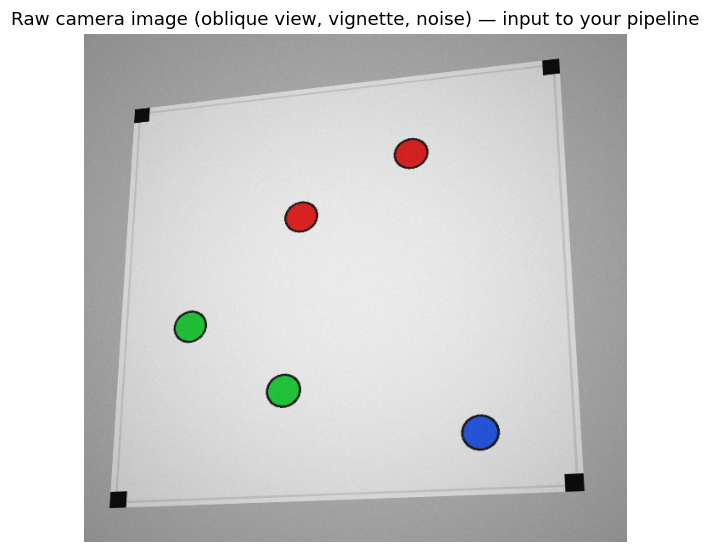

Image shape: (600, 640, 3)


In [ ]:
# ============================================================
#   A.1  —  Synthetic workbench image generator (camera driver)
# ============================================================
# Bench dimensions in metres (the robot's working area)
BENCH_HALF = 0.30                 # ± 0.30 m on both axes
WORLD_CORNERS_M = np.array([      # in robot-base frame  (x, y)
    [+0.30, +0.30],   # TL
    [+0.30, -0.30],   # TR
    [-0.30, -0.30],   # BR
    [-0.30, +0.30],   # BL
], dtype=np.float32)

# Ground-truth coloured discs (NOT visible to the student pipeline)
GROUND_TRUTH_DISCS = [
    {"color": "red",   "world_xy": (+0.18, -0.10)},
    {"color": "green", "world_xy": (-0.05, +0.20)},
    {"color": "blue",  "world_xy": (-0.22, -0.18)},
    {"color": "red",   "world_xy": (+0.10, +0.05)},
    {"color": "green", "world_xy": (-0.15, +0.07)},
]

DISC_RGB = {"red":   (220,  35,  35),
            "green": ( 35, 200,  60),
            "blue":  ( 40,  90, 230)}


def _render_topdown_truth(canvas_size=600):
    """Render an ideal (un-distorted) top-down RGB view of the bench."""
    img = np.full((canvas_size, canvas_size, 3), 235, dtype=np.uint8)  # light-gray bench

    # Helper: world (m) -> pixel (px) in this canonical canvas
    def w2p(xy):
        # World x grows UP on the bench, world y grows LEFT (right-handed,
        # z up). In the top-down image:  u = (canvas/2) - y/half * canvas/2
        #                                v = (canvas/2) - x/half * canvas/2
        u = int((canvas_size/2) - (xy[1] / BENCH_HALF) * (canvas_size/2))
        v = int((canvas_size/2) - (xy[0] / BENCH_HALF) * (canvas_size/2))
        return (u, v)

    # Bench border (subtle)
    cv2.rectangle(img, (8, 8), (canvas_size-8, canvas_size-8), (210, 210, 210), 2)

    # 1.  Black corner markers — 40-px squares
    msz = 22
    for w_xy in WORLD_CORNERS_M:
        u, v = w2p(w_xy)
        cv2.rectangle(img, (u-msz, v-msz), (u+msz, v+msz), (15, 15, 15), -1)

    # 2.  Coloured discs
    for d in GROUND_TRUTH_DISCS:
        u, v = w2p(d["world_xy"])
        bgr = DISC_RGB[d["color"]][::-1]
        cv2.circle(img, (u, v), 22, bgr, -1)
        cv2.circle(img, (u, v), 22, (30, 30, 30), 2)   # outline

    return img


def capture_workbench_image(seed=7):
    """Return the *raw* camera image: tilted view, vignetting, Gaussian noise."""
    rng = np.random.default_rng(seed)

    truth = _render_topdown_truth(600)

    # Apply a fixed projective distortion (camera looking from upper-right)
    src = np.float32([[0, 0], [600, 0], [600, 600], [0, 600]])
    dst = np.float32([[ 60,  90],
                      [560,  30],
                      [590, 540],
                      [ 30, 560]])
    H = cv2.getPerspectiveTransform(src, dst)
    warped = cv2.warpPerspective(truth, H, (640, 600),
                                 borderValue=(180, 180, 180))

    # Vignette
    rows, cols = warped.shape[:2]
    kx = cv2.getGaussianKernel(cols, cols/1.6)
    ky = cv2.getGaussianKernel(rows, rows/1.6)
    mask = (ky @ kx.T)
    mask = mask / mask.max()
    warped = (warped.astype(np.float32) * (0.55 + 0.45*mask[..., None])).clip(0, 255)

    # Mild Gaussian noise
    noise = rng.normal(0, 4.0, warped.shape)
    warped = (warped + noise).clip(0, 255).astype(np.uint8)
    return warped


# Capture and display
raw = capture_workbench_image()
plt.figure(figsize=(7, 6))
plt.imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB))
plt.title("Raw camera image (oblique view, vignette, noise) — input to your pipeline")
plt.axis('off')
plt.show()
print(f"Image shape: {raw.shape}")


## C.1 — PRR URDF as a Python string

We embed the URDF text directly in the notebook so the assignment is fully self-contained.


In [ ]:
# ============================================================
#   C.1 — Author the PRR URDF in-place
# ============================================================
URDF_TEXT = f"""\
<?xml version="1.0"?>
<robot name="prr_robot">

  <!-- ===== Inertial helpers =================================== -->
  <!-- Just a fixed root so the prismatic joint has a parent. -->
  <link name="base_link">
    <visual>
      <geometry><cylinder radius="0.18" length="0.20"/></geometry>
      <origin xyz="0 0 0.10"/>
      <material name="dark"><color rgba="0.25 0.25 0.27 1"/></material>
    </visual>
    <collision>
      <geometry><cylinder radius="0.18" length="0.20"/></geometry>
      <origin xyz="0 0 0.10"/>
    </collision>
    <inertial>
      <mass value="10"/>
      <inertia ixx="0.2" ixy="0" ixz="0" iyy="0.2" iyz="0" izz="0.2"/>
    </inertial>
  </link>

  <!-- ===== Link 1 — vertical column (sliding) ================= -->
  <link name="link1">
    <visual>
      <geometry><box size="0.10 0.10 0.50"/></geometry>
      <origin xyz="0 0 0.25"/>
      <material name="blue"><color rgba="0.20 0.45 0.85 1"/></material>
    </visual>
    <collision>
      <geometry><box size="0.10 0.10 0.50"/></geometry>
      <origin xyz="0 0 0.25"/>
    </collision>
    <inertial>
      <mass value="2.5"/>
      <origin xyz="0 0 0.25"/>
      <inertia ixx="0.06" ixy="0" ixz="0" iyy="0.06" iyz="0" izz="0.01"/>
    </inertial>
  </link>

  <joint name="j1_prismatic" type="prismatic">
    <parent link="base_link"/>
    <child  link="link1"/>
    <origin xyz="0 0 0.20"/>
    <axis   xyz="0 0 1"/>
    <limit  lower="{Q1_MIN}" upper="{Q1_MAX}" effort="200" velocity="1"/>
  </joint>

  <!-- ===== Link 2 — horizontal arm (revolute about z) ========= -->
  <link name="link2">
    <visual>
      <geometry><box size="{L2} 0.07 0.07"/></geometry>
      <origin xyz="{L2/2} 0 0"/>
      <material name="orange"><color rgba="0.95 0.55 0.10 1"/></material>
    </visual>
    <collision>
      <geometry><box size="{L2} 0.07 0.07"/></geometry>
      <origin xyz="{L2/2} 0 0"/>
    </collision>
    <inertial>
      <mass value="1.0"/>
      <origin xyz="{L2/2} 0 0"/>
      <inertia ixx="0.005" ixy="0" ixz="0" iyy="0.030" iyz="0" izz="0.030"/>
    </inertial>
  </link>

  <joint name="j2_revolute" type="continuous">
    <parent link="link1"/>
    <child  link="link2"/>
    <origin xyz="0 0 0.50"/>
    <axis   xyz="0 0 1"/>
  </joint>

  <!-- ===== Link 3 — forearm (revolute about z) ================ -->
  <link name="link3">
    <visual>
      <geometry><box size="{L3} 0.06 0.06"/></geometry>
      <origin xyz="{L3/2} 0 0"/>
      <material name="green"><color rgba="0.20 0.75 0.30 1"/></material>
    </visual>
    <collision>
      <geometry><box size="{L3} 0.06 0.06"/></geometry>
      <origin xyz="{L3/2} 0 0"/>
    </collision>
    <inertial>
      <mass value="0.7"/>
      <origin xyz="{L3/2} 0 0"/>
      <inertia ixx="0.003" ixy="0" ixz="0" iyy="0.020" iyz="0" izz="0.020"/>
    </inertial>
  </link>

  <joint name="j3_revolute" type="continuous">
    <parent link="link2"/>
    <child  link="link3"/>
    <origin xyz="{L2} 0 0"/>
    <axis   xyz="0 0 1"/>
  </joint>

  <!-- ===== End-effector marker ================================ -->
  <link name="ee">
    <visual>
      <geometry><sphere radius="0.025"/></geometry>
      <material name="yellow"><color rgba="1.0 0.85 0.10 1"/></material>
    </visual>
    <collision>
      <geometry><sphere radius="0.025"/></geometry>
    </collision>
    <inertial>
      <mass value="0.05"/>
      <inertia ixx="1e-5" ixy="0" ixz="0" iyy="1e-5" iyz="0" izz="1e-5"/>
    </inertial>
  </link>

  <joint name="ee_fixed" type="fixed">
    <parent link="link3"/>
    <child  link="ee"/>
    <origin xyz="{L3} 0 0"/>
  </joint>

</robot>
"""

# Persist to a temporary path so loadURDF can find it.
URDF_PATH = os.path.join(tempfile.gettempdir(), "prr_robot.urdf")
with open(URDF_PATH, "w") as f:
    f.write(URDF_TEXT)
print(f"URDF written to {URDF_PATH}  ({len(URDF_TEXT)} bytes)")


URDF written to /tmp/prr_robot.urdf  (3570 bytes)
